In [ ]:
# ============================================================
# CELL 1: Setup
# ============================================================
!pip install -q imbalanced-learn gdown

import os, random, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
warnings.filterwarnings('ignore')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
    'text.color': '#e6edf3', 'grid.color': '#21262d', 'grid.linestyle': '--',
    'font.size': 11
})

print(f'TensorFlow: {tf.__version__} | GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')
print('✅ Setup complete!')

TensorFlow: 2.20.0 | GPU: False
✅ Setup complete!


In [ ]:
# ============================================================
# CELL 2: Dataset Loading
# ============================================================
if not os.path.exists('creditcard.csv') or os.path.getsize('creditcard.csv') < 1000:
    print('Generating synthetic dataset for demonstration...')
    print('Upload creditcard.csv from Kaggle for real results!')
    np.random.seed(SEED)
    n_legit, n_fraud = 28000, 492
    legit_feat = np.random.randn(n_legit, 28)
    fraud_feat = np.random.randn(n_fraud, 28) * 1.5 + 0.5
    cols = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount', 'Class']
    legit_df = pd.DataFrame(np.column_stack([
        np.sort(np.random.uniform(0, 172800, n_legit)), legit_feat,
        np.abs(np.random.exponential(50, n_legit)), np.zeros(n_legit)]), columns=cols)
    fraud_df = pd.DataFrame(np.column_stack([
        np.sort(np.random.uniform(0, 172800, n_fraud)), fraud_feat,
        np.abs(np.random.exponential(120, n_fraud)), np.ones(n_fraud)]), columns=cols)
    df = pd.concat([legit_df, fraud_df]).sort_values('Time').reset_index(drop=True)
    df['Class'] = df['Class'].astype(int)
    USING_SYNTHETIC = True
else:
    df = pd.read_csv('creditcard.csv')
    USING_SYNTHETIC = False

print(f'Dataset: {df.shape} | Fraud: {df["Class"].sum():,} ({100*df["Class"].mean():.3f}%)')
print(f'Time range: {df["Time"].min():.0f}s – {df["Time"].max():.0f}s ({df["Time"].max()/3600:.1f} hours)')

Generating synthetic dataset for demonstration...
Upload creditcard.csv from Kaggle for real results!
Dataset: (28492, 31) | Fraud: 492 (1.727%)
Time range: 15s – 172798s (48.0 hours)


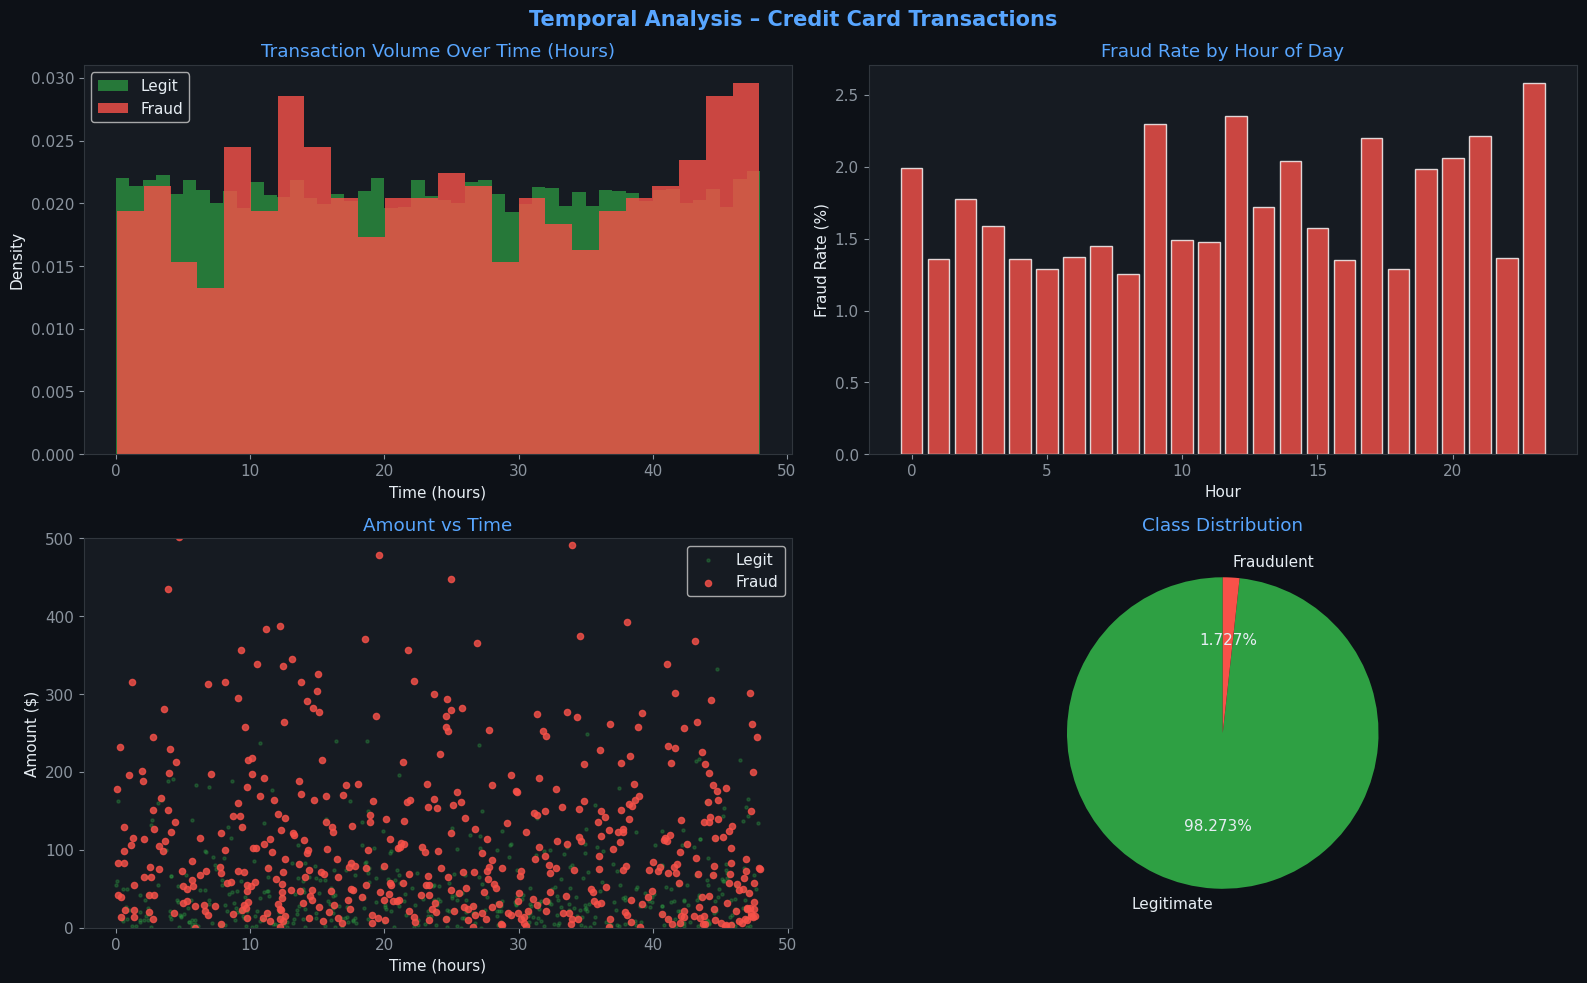

In [ ]:
# ============================================================
# CELL 3: EDA – Temporal analysis
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Temporal Analysis – Credit Card Transactions', fontsize=15, fontweight='bold', color='#58a6ff')

# Transactions over time
df['Time_hr'] = df['Time'] / 3600
axes[0, 0].hist(df[df['Class']==0]['Time_hr'], bins=48, color='#2ea043', alpha=0.7, label='Legit', density=True)
axes[0, 0].hist(df[df['Class']==1]['Time_hr'], bins=24, color='#f85149', alpha=0.8, label='Fraud', density=True)
axes[0, 0].set_title('Transaction Volume Over Time (Hours)', color='#58a6ff')
axes[0, 0].set_xlabel('Time (hours)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()

# Fraud by hour-of-day (modulo 24h assuming 2-day window)
df['Hour'] = df['Time_hr'].apply(lambda x: int(x % 24))
fraud_by_hour  = df[df['Class']==1].groupby('Hour').size()
legit_by_hour  = df[df['Class']==0].groupby('Hour').size()
fraud_rate_hour = fraud_by_hour / (fraud_by_hour + legit_by_hour.reindex(fraud_by_hour.index, fill_value=0))
axes[0, 1].bar(fraud_rate_hour.index, fraud_rate_hour.values * 100, color='#f85149', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Fraud Rate by Hour of Day', color='#58a6ff')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Fraud Rate (%)')

# Amount vs Time (fraud vs legit)
sample_legit = df[df['Class']==0].sample(500, random_state=SEED)
sample_fraud = df[df['Class']==1]
axes[1, 0].scatter(sample_legit['Time_hr'], sample_legit['Amount'], alpha=0.3, color='#2ea043', s=5, label='Legit')
axes[1, 0].scatter(sample_fraud['Time_hr'],  sample_fraud['Amount'],  alpha=0.8, color='#f85149', s=20, label='Fraud')
axes[1, 0].set_title('Amount vs Time', color='#58a6ff')
axes[1, 0].set_xlabel('Time (hours)')
axes[1, 0].set_ylabel('Amount ($)')
axes[1, 0].set_ylim(0, 500)
axes[1, 0].legend()

# Class distribution
class_counts = df['Class'].value_counts()
axes[1, 1].pie(class_counts.values, labels=['Legitimate', 'Fraudulent'],
               colors=['#2ea043', '#f85149'], autopct='%1.3f%%', startangle=90)
axes[1, 1].set_title('Class Distribution', color='#58a6ff')

plt.tight_layout()
plt.savefig('lstm_eda.png', dpi=150, bbox_inches='tight')
plt.show()

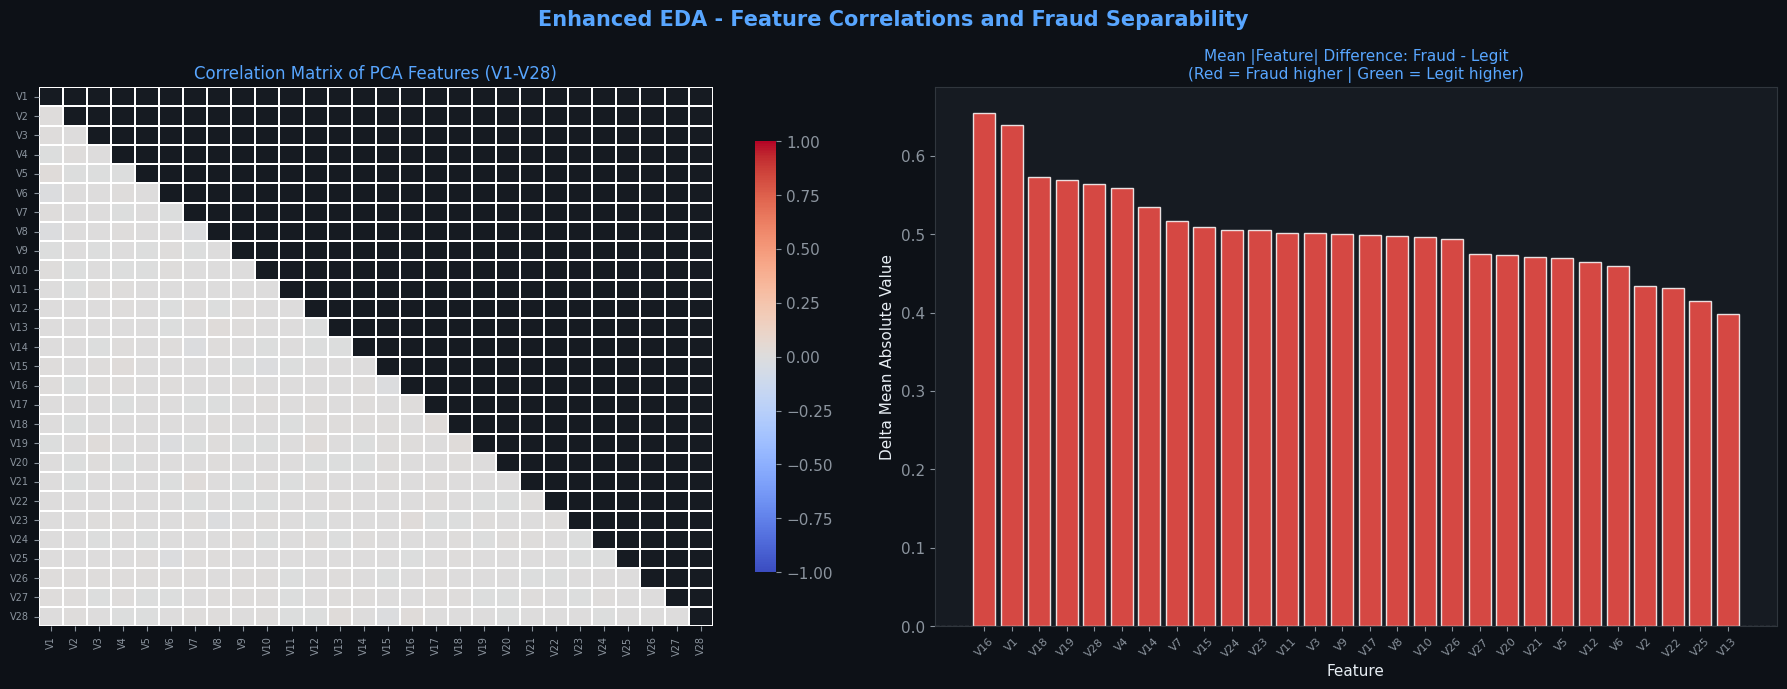

Enhanced EDA saved to lstm_feature_analysis.png


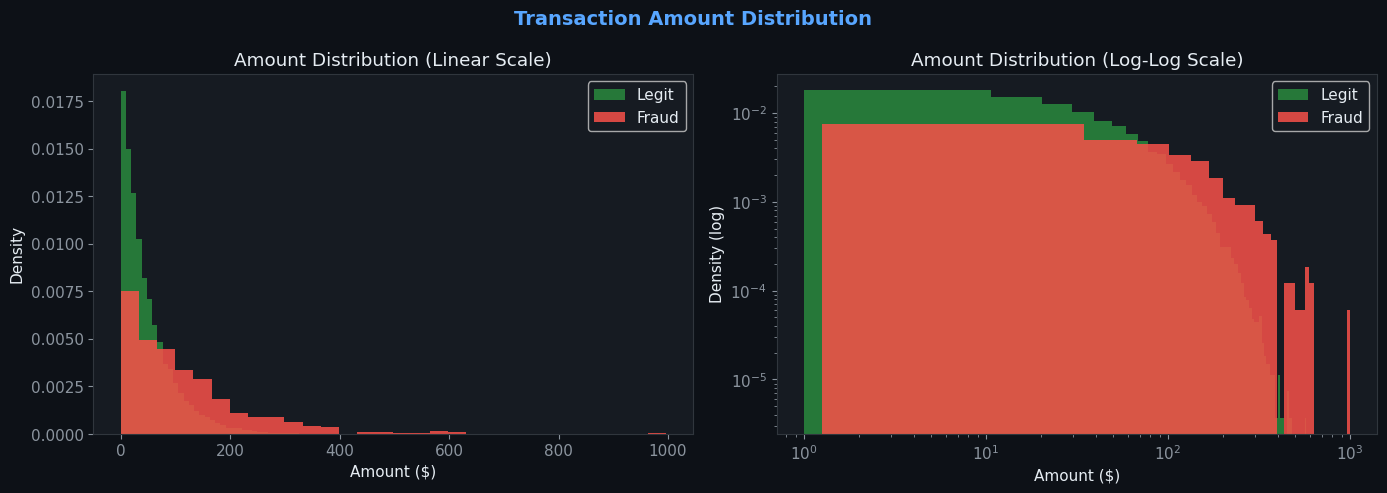

Amount distribution saved to lstm_amount_distribution.png


In [ ]:
# ============================================================
# CELL 3b: Enhanced EDA - Correlation Heatmap and Feature Analysis
# ============================================================

# --- Correlation heatmap of V1-V28 ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Enhanced EDA - Feature Correlations and Fraud Separability',
             fontsize=15, fontweight='bold', color='#58a6ff')

v_cols = [f'V{i}' for i in range(1, 29)]
corr = df[v_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=axes[0], cmap='coolwarm', center=0,
    vmin=-1, vmax=1, annot=False, linewidths=0.3,
    cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Correlation Matrix of PCA Features (V1-V28)', color='#58a6ff', fontsize=12)
axes[0].tick_params(axis='both', labelsize=7)

# --- Mean |feature| difference: Fraud vs Legit ---
fraud_mean = df[df['Class'] == 1][v_cols].mean().abs()
legit_mean = df[df['Class'] == 0][v_cols].mean().abs()
diff = (fraud_mean - legit_mean).sort_values(ascending=False)
bar_colors = ['#f85149' if v > 0 else '#2ea043' for v in diff.values]
axes[1].bar(diff.index, diff.values, color=bar_colors, edgecolor='white', alpha=0.85)
axes[1].axhline(0, color='white', linewidth=0.8, linestyle='--')
axes[1].set_title(
    'Mean |Feature| Difference: Fraud - Legit\n(Red = Fraud higher | Green = Legit higher)',
    color='#58a6ff', fontsize=11)
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Delta Mean Absolute Value')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.savefig('lstm_feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Enhanced EDA saved to lstm_feature_analysis.png')

# --- Amount distribution (linear + log scale) ---
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Transaction Amount Distribution', fontsize=14, fontweight='bold', color='#58a6ff')

axes2[0].hist(df[df['Class'] == 0]['Amount'], bins=60, color='#2ea043', alpha=0.7,
              label='Legit', density=True)
axes2[0].hist(df[df['Class'] == 1]['Amount'], bins=30, color='#f85149', alpha=0.85,
              label='Fraud', density=True)
axes2[0].set_title('Amount Distribution (Linear Scale)')
axes2[0].set_xlabel('Amount ($)')
axes2[0].set_ylabel('Density')
axes2[0].legend()

axes2[1].hist(df[df['Class'] == 0]['Amount'] + 1, bins=60, color='#2ea043', alpha=0.7,
              label='Legit', density=True)
axes2[1].hist(df[df['Class'] == 1]['Amount'] + 1, bins=30, color='#f85149', alpha=0.85,
              label='Fraud', density=True)
axes2[1].set_yscale('log')
axes2[1].set_xscale('log')
axes2[1].set_title('Amount Distribution (Log-Log Scale)')
axes2[1].set_xlabel('Amount ($)')
axes2[1].set_ylabel('Density (log)')
axes2[1].legend()

plt.tight_layout()
plt.savefig('lstm_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Amount distribution saved to lstm_amount_distribution.png')

In [ ]:
# ============================================================
# CELL 4: Preprocessing and sequence reshaping
# ============================================================
# Feature scaling
X = df.drop(['Class', 'Time_hr', 'Hour'], axis=1).copy()
y = df['Class'].values

X['Time']   = StandardScaler().fit_transform(X[['Time']])
X['Amount'] = StandardScaler().fit_transform(X[['Amount']])
X_array = X.values

# Train/Val/Test split (70/15/15) BEFORE SMOTE
X_temp, X_test, y_temp, y_test = train_test_split(
    X_array, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp)

# Apply SMOTE to training set only
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Splits:')
print(f'  Train (after SMOTE): {X_train_sm.shape}')
print(f'  Val:                 {X_val.shape}')
print(f'  Test:                {X_test.shape}')

Splits:
  Train (after SMOTE): (39198, 30)
  Val:                 (4275, 30)
  Test:                (4274, 30)


In [ ]:
# ============================================================
# CELL 5: Reshape data for LSTM input
# LSTM expects: (samples, timesteps, features)
#
# Strategy: reshape each 30-feature vector into (6 timesteps × 5 features)
# This simulates processing feature groups sequentially:
#   Step 1: Time, V1-V4
#   Step 2: V5-V9
#   Step 3: V10-V14
#   Step 4: V15-V19
#   Step 5: V20-V24
#   Step 6: V25-V28, Amount
# ============================================================
TIMESTEPS = 6
N_FEATURES_PER_STEP = X_train_sm.shape[1] // TIMESTEPS

# Ensure divisibility
total_features = TIMESTEPS * N_FEATURES_PER_STEP
if X_train_sm.shape[1] != total_features:
    # Pad with zeros to make divisible
    pad = total_features - X_train_sm.shape[1]
    X_train_sm = np.pad(X_train_sm, ((0,0),(0,pad)), mode='constant')
    X_val   = np.pad(X_val,   ((0,0),(0,pad)), mode='constant')
    X_test  = np.pad(X_test,  ((0,0),(0,pad)), mode='constant')
    print(f'Padded features from {X.shape[1]} to {total_features}')

X_train_lstm = X_train_sm.reshape(-1, TIMESTEPS, N_FEATURES_PER_STEP)
X_val_lstm   = X_val.reshape(-1,    TIMESTEPS, N_FEATURES_PER_STEP)
X_test_lstm  = X_test.reshape(-1,   TIMESTEPS, N_FEATURES_PER_STEP)

print(f'LSTM input shape: (samples, timesteps={TIMESTEPS}, features/step={N_FEATURES_PER_STEP})')
print(f'Train: {X_train_lstm.shape} | Val: {X_val_lstm.shape} | Test: {X_test_lstm.shape}')

LSTM input shape: (samples, timesteps=6, features/step=5)
Train: (39198, 6, 5) | Val: (4275, 6, 5) | Test: (4274, 6, 5)


In [ ]:
# ============================================================
# CELL 6: Build LSTM model
# Architecture justification:
#   - 2 stacked LSTM layers: first captures short-range dependencies,
#     second captures higher-level temporal patterns
#   - LSTM(64): larger capacity for learning diverse transaction patterns
#   - LSTM(32): narrower for higher-level feature extraction
#   - return_sequences=True on first LSTM: passes full sequence to second layer
#   - Dropout(0.3): prevents overfitting on sequential data
#   - Dense(16): final feature integration layer
#   - Sigmoid output: binary fraud probability
#   - Adam optimizer with lower lr: stable training for RNNs
#   - Binary Cross-Entropy: appropriate for binary classification
# ============================================================
def build_lstm(timesteps, n_features, dropout=0.3, l2_reg=1e-4):
    inp = layers.Input(shape=(timesteps, n_features), name='lstm_input')

    # First LSTM layer – return sequences for stacking
    x = layers.LSTM(
        64, return_sequences=True,
        kernel_regularizer=regularizers.l2(l2_reg),
        recurrent_regularizer=regularizers.l2(l2_reg),
        name='lstm_1'
    )(inp)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(dropout, name='dropout_1')(x)

    # Second LSTM layer – outputs final hidden state only
    x = layers.LSTM(
        32,
        kernel_regularizer=regularizers.l2(l2_reg),
        recurrent_regularizer=regularizers.l2(l2_reg),
        name='lstm_2'
    )(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(dropout, name='dropout_2')(x)

    # Dense classification head
    x = layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(l2_reg), name='dense_1')(x)
    x = layers.Dropout(0.2, name='dropout_3')(x)

    # Output
    out = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out, name='LSTM_FraudDetector')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

lstm_model = build_lstm(TIMESTEPS, N_FEATURES_PER_STEP)
lstm_model.summary()

Model: "LSTM_FraudDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_input (InputLayer)         │ (None, 6, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 6, 64)          │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 6, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,265 (122.13 KB)

 Trainable params: 31,073 (121.38 KB)

 Non-trainable params: 192 (768.00 B)

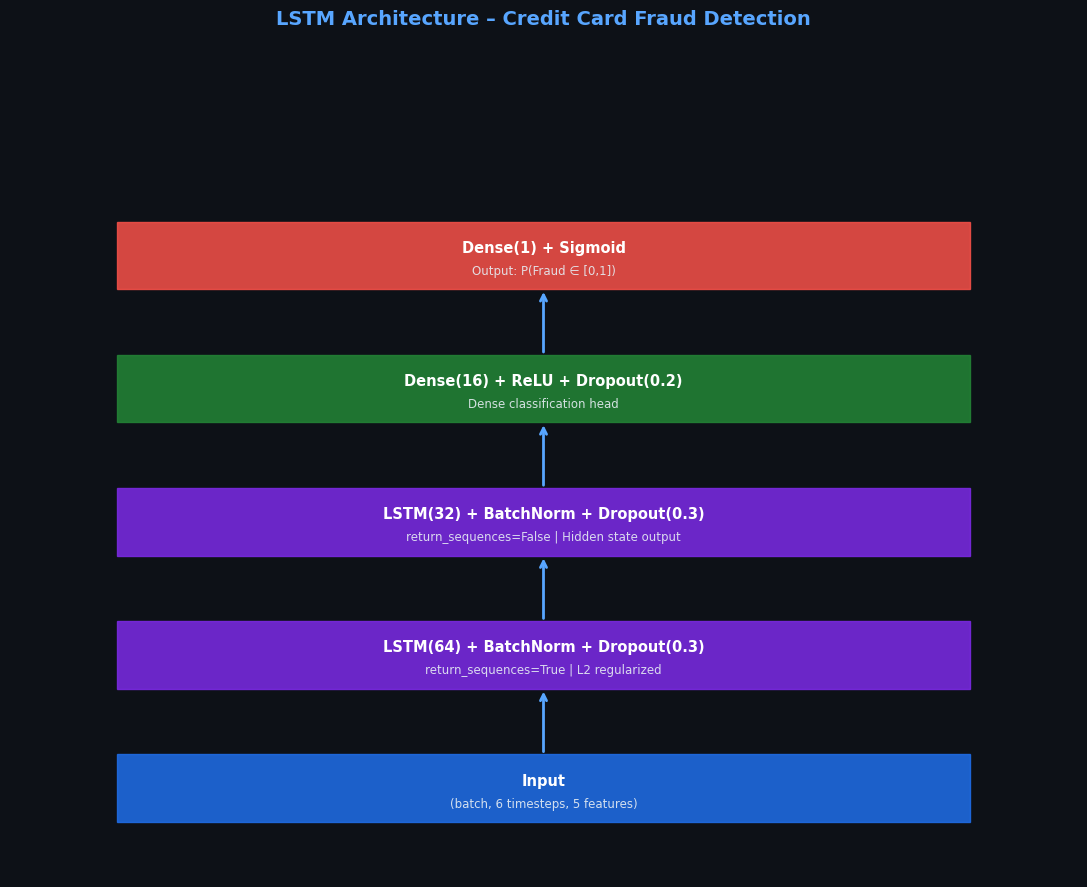

In [ ]:
# ============================================================
# CELL 7: Architecture visualization
# ============================================================
fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')
ax.set_xlim(0, 10)
ax.set_ylim(-0.5, 9)
ax.axis('off')
ax.set_title('LSTM Architecture – Credit Card Fraud Detection', fontsize=14, fontweight='bold', color='#58a6ff')

layers_vis = [
    (0.5, 'Input', f'(batch, {TIMESTEPS} timesteps, {N_FEATURES_PER_STEP} features)', '#1f6feb'),
    (2.0, 'LSTM(64) + BatchNorm + Dropout(0.3)', 'return_sequences=True | L2 regularized', '#7d2ae8'),
    (3.5, 'LSTM(32) + BatchNorm + Dropout(0.3)', 'return_sequences=False | Hidden state output', '#7d2ae8'),
    (5.0, 'Dense(16) + ReLU + Dropout(0.2)', 'Dense classification head', '#238636'),
    (6.5, 'Dense(1) + Sigmoid', 'Output: P(Fraud ∈ [0,1])', '#f85149'),
]

for y_pos, title, subtitle, color in layers_vis:
    rect = plt.Rectangle((1.0, y_pos - 0.38), 8, 0.76, color=color, alpha=0.85, zorder=3)
    ax.add_patch(rect)
    ax.text(5, y_pos + 0.08, title, ha='center', va='center', fontsize=10.5, fontweight='bold', color='white', zorder=4)
    ax.text(5, y_pos - 0.18, subtitle, ha='center', va='center', fontsize=8.5, color='#e6edf3', alpha=0.9, zorder=4)

for i in range(len(layers_vis) - 1):
    y1, y2 = layers_vis[i][0] + 0.38, layers_vis[i+1][0] - 0.38
    ax.annotate('', xy=(5, y2), xytext=(5, y1), arrowprops=dict(arrowstyle='->', color='#58a6ff', lw=2))

plt.tight_layout()
plt.savefig('lstm_architecture.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# CELL 8: Training
# ============================================================
callbacks = [
    EarlyStopping(monitor='val_auc', patience=10, mode='max', restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_lstm_model.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

print('🚀 Training LSTM...')
history = lstm_model.fit(
    X_train_lstm, y_train_sm,
    validation_data=(X_val_lstm, y_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)
print(f'\n✅ Training complete! Best epoch: {np.argmax(history.history["val_auc"]) + 1}')

🚀 Training LSTM...
Epoch 1/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.8647 - auc: 0.9412 - loss: 0.3357 - precision: 0.8394 - recall: 0.9021 - val_accuracy: 0.9885 - val_auc: 0.9770 - val_loss: 0.2637 - val_precision: 0.6712 - val_recall: 0.6622 - learning_rate: 5.0000e-04
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9224 - auc: 0.9753 - loss: 0.2203 - precision: 0.9180 - recall: 0.9276 - val_accuracy: 0.9850 - val_auc: 0.9837 - val_loss: 0.0906 - val_precision: 0.5410 - val_recall: 0.8919 - learning_rate: 5.0000e-04
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9362 - auc: 0.9820 - loss: 0.1884 - precision: 0.9299 - recall: 0.9436 - val_accuracy: 0.9619 - val_auc: 0.9876 - val_loss: 0.1092 - val_precision: 0.3057 - val_recall: 0.9459 - learning_rate: 5.0000e-04
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9421 - auc: 0.9858 - loss: 0.1682 - precision: 0.9326 - recall: 0.9532 - val_accuracy: 0.9553 - 

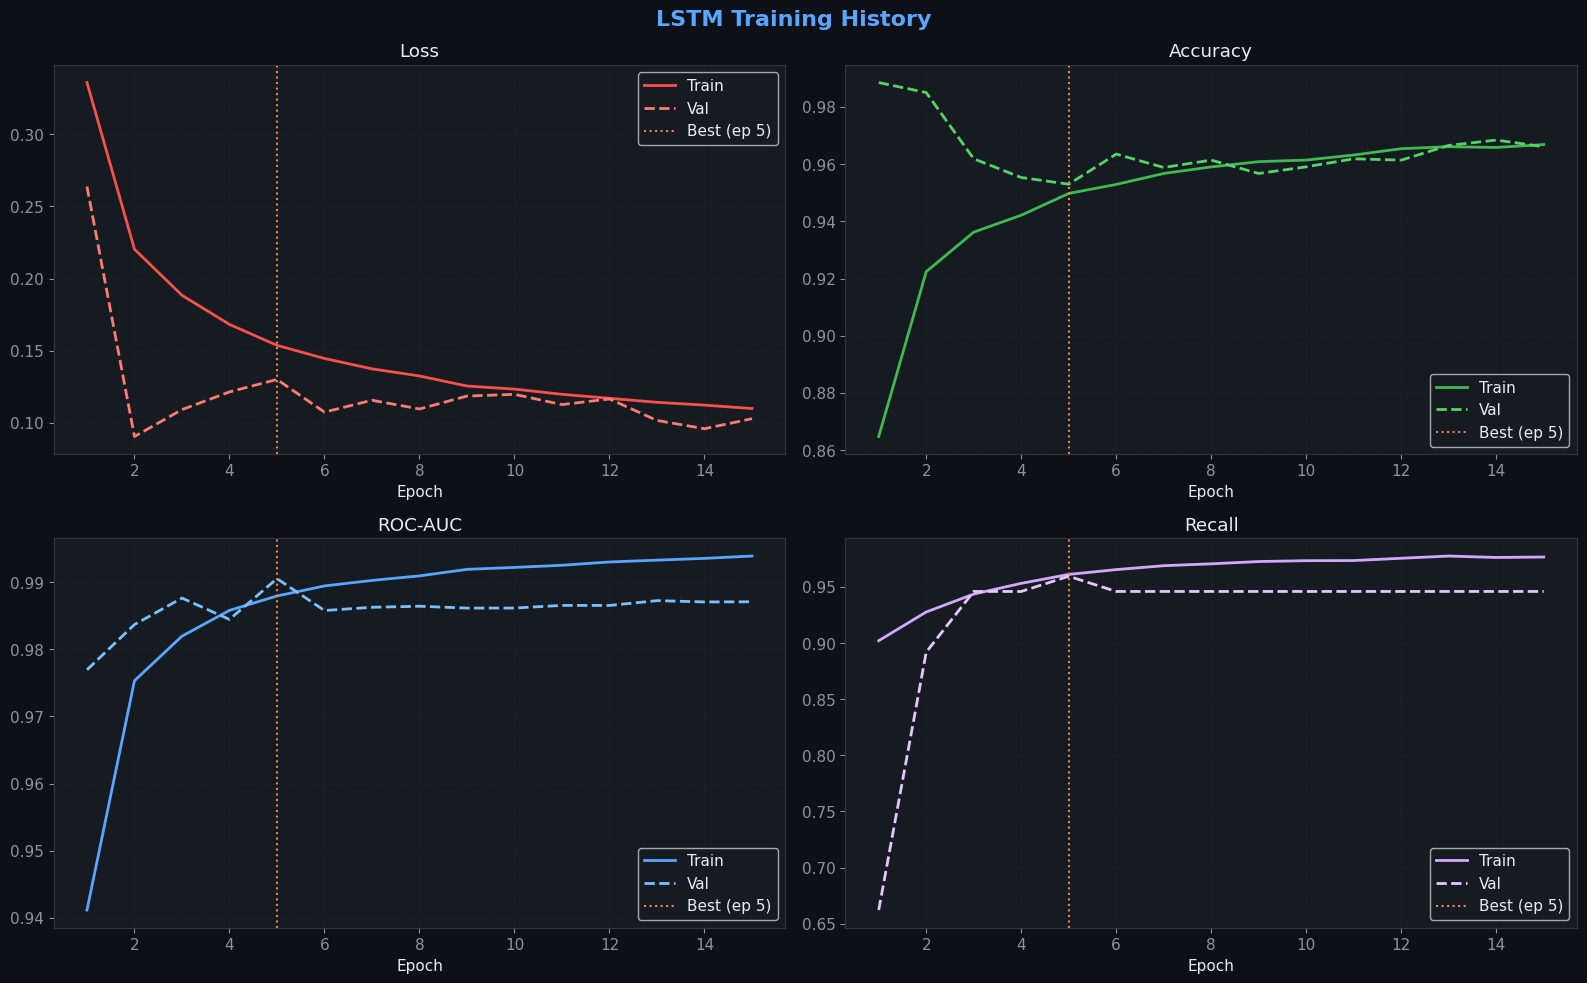

In [ ]:
# ============================================================
# CELL 9: Training history
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('LSTM Training History', fontsize=16, fontweight='bold', color='#58a6ff')

metric_pairs = [
    ('loss', 'val_loss', 'Loss', '#f85149', '#ff7b72'),
    ('accuracy', 'val_accuracy', 'Accuracy', '#3fb950', '#56d364'),
    ('auc', 'val_auc', 'ROC-AUC', '#58a6ff', '#79c0ff'),
    ('recall', 'val_recall', 'Recall', '#d2a8ff', '#e6c6ff'),
]

for ax, (tk, vk, title, c1, c2) in zip(axes.flatten(), metric_pairs):
    ep = range(1, len(history.history[tk]) + 1)
    ax.plot(ep, history.history[tk], color=c1, linewidth=2, label='Train')
    ax.plot(ep, history.history[vk], color=c2, linewidth=2, linestyle='--', label='Val')
    best_ep = np.argmax(history.history['val_auc']) + 1
    ax.axvline(best_ep, color='#f0883e', linestyle=':', linewidth=1.5, label=f'Best (ep {best_ep})')
    ax.set_title(title, color='#e6edf3')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# CELL 10: Threshold tuning + Final Test Evaluation
# ============================================================
y_val_prob  = lstm_model.predict(X_val_lstm, verbose=0).flatten()
thresholds  = np.arange(0.1, 0.9, 0.01)
f1_scores   = [f1_score(y_val, (y_val_prob >= t).astype(int)) for t in thresholds]
optimal_thr = thresholds[np.argmax(f1_scores)]
print(f'Optimal threshold: {optimal_thr:.2f} | Best val F1: {max(f1_scores):.4f}')

# ── Test evaluation ──
y_test_prob = lstm_model.predict(X_test_lstm, verbose=0).flatten()
y_test_pred = (y_test_prob >= optimal_thr).astype(int)

acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec  = recall_score(y_test, y_test_pred)
f1   = f1_score(y_test, y_test_pred)
auc  = roc_auc_score(y_test, y_test_prob)

print('='*55)
print('       LSTM – TEST SET RESULTS')
print('='*55)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {auc:.4f}')
print('='*55)
print()
print(classification_report(y_test, y_test_pred, target_names=['Legitimate', 'Fraudulent']))

Optimal threshold: 0.89 | Best val F1: 0.7302
       LSTM – TEST SET RESULTS
  Accuracy  : 0.9902  (99.02%)
  Precision : 0.6600
  Recall    : 0.8919
  F1-Score  : 0.7586
  ROC-AUC   : 0.9923

              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99      4200
  Fraudulent       0.66      0.89      0.76        74

    accuracy                           0.99      4274
   macro avg       0.83      0.94      0.88      4274
weighted avg       0.99      0.99      0.99      4274



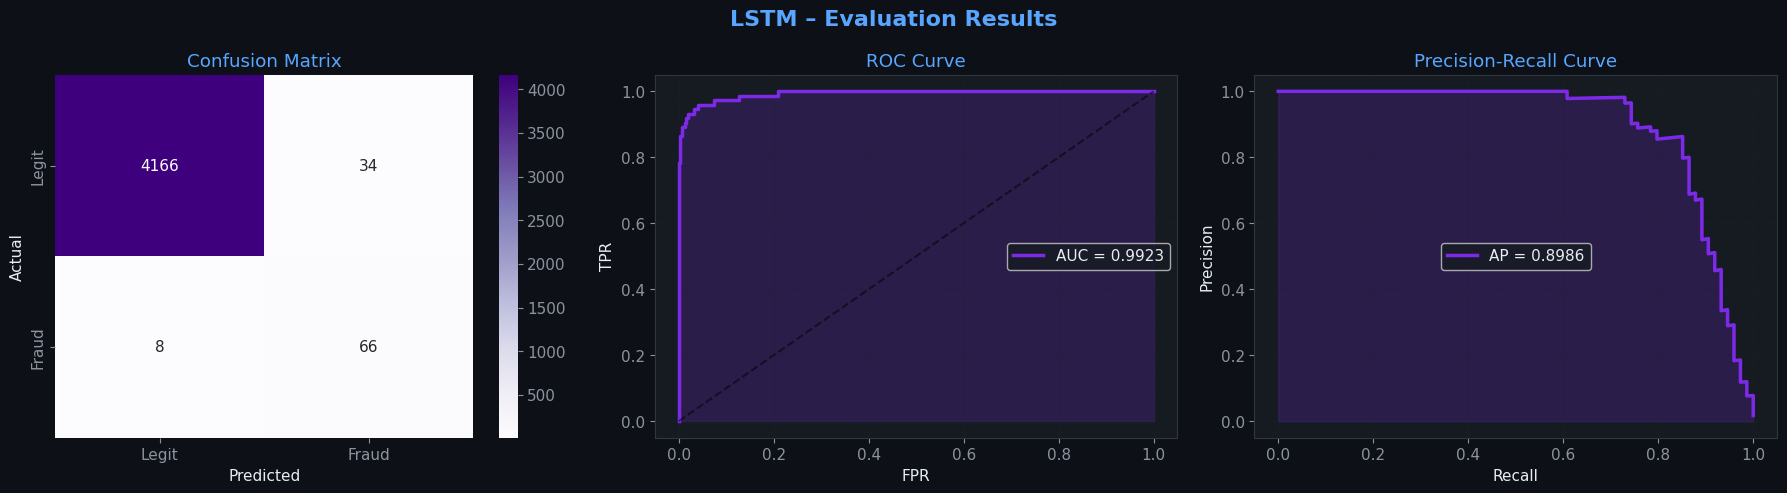

In [ ]:
# ============================================================
# CELL 11: Evaluation visualizations
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('LSTM – Evaluation Results', fontsize=16, fontweight='bold', color='#58a6ff')

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'], ax=axes[0])
axes[0].set_title('Confusion Matrix', color='#58a6ff')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
axes[1].plot(fpr, tpr, color='#7d2ae8', linewidth=2.5, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--',alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.2, color='#7d2ae8')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve', color='#58a6ff')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# PR Curve
pc, rc, _ = precision_recall_curve(y_test, y_test_prob)
ap = average_precision_score(y_test, y_test_prob)
axes[2].plot(rc, pc, color='#7d2ae8', linewidth=2.5, label=f'AP = {ap:.4f}')
axes[2].fill_between(rc, pc, alpha=0.2, color='#7d2ae8')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', color='#58a6ff')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

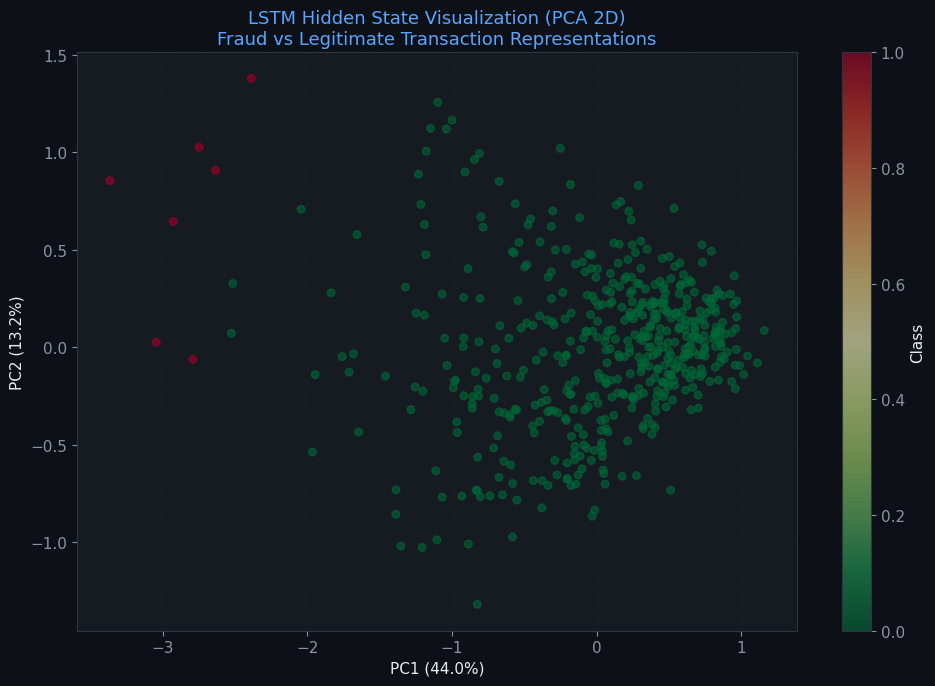

In [ ]:
# ============================================================
# CELL 12: Hidden state analysis (LSTM interpretability)
# ============================================================
import tensorflow as tf
from tensorflow import keras
from sklearn.decomposition import PCA

# Extract hidden states from the second LSTM layer (lstm_2)
lstm_layer_output_model = tf.keras.Model(
    inputs=lstm_model.input,
    outputs=lstm_model.get_layer('lstm_2').output
)

# Get hidden states for test samples
n_samples = min(500, len(X_test_lstm))
hidden_states = lstm_layer_output_model.predict(X_test_lstm[:n_samples], verbose=0)
y_test_sample = y_test[:n_samples]

pca = PCA(n_components=2, random_state=SEED)
hs_2d = pca.fit_transform(hidden_states)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(hs_2d[:, 0], hs_2d[:, 1],
                      c=y_test_sample, cmap='RdYlGn_r', alpha=0.6, s=30)
plt.colorbar(scatter, label='Class')
plt.title('LSTM Hidden State Visualization (PCA 2D)\nFraud vs Legitimate Transaction Representations',
          color='#58a6ff', fontsize=13)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_hidden_states.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# CELL 13: Save results
# ============================================================
lstm_model.save('lstm_fraud_model.keras')

summary = {
    'model': 'LSTM',
    'author': 'Diluka',
    'accuracy': round(acc, 4),
    'precision': round(prec, 4),
    'recall': round(rec, 4),
    'f1': round(f1, 4),
    'roc_auc': round(auc, 4),
    'optimal_threshold': round(float(optimal_thr), 2),
    'architecture': f'({TIMESTEPS},{N_FEATURES_PER_STEP})→LSTM(64)→LSTM(32)→Dense(16)→1',
    'params': lstm_model.count_params()
}
with open('lstm_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

pd.DataFrame({'Metric': ['Accuracy','Precision','Recall','F1','ROC-AUC'],
              'Test': [acc, prec, rec, f1, auc]}).round(4).to_csv('lstm_results.csv', index=False)

print('✅ LSTM model and results saved!')
print('\n📊 Final Results:')
for k, v in summary.items():
    print(f'  {k:20s}: {v}')

✅ LSTM model and results saved!

📊 Final Results:
  model               : LSTM
  author              : Diluka
  accuracy            : 0.9902
  precision           : 0.66
  recall              : 0.8919
  f1                  : 0.7586
  roc_auc             : 0.9923
  optimal_threshold   : 0.89
  architecture        : (6,5)→LSTM(64)→LSTM(32)→Dense(16)→1
  params              : 31265


In [ ]:
# ============================================================
# CELL 13b: Export metrics for Main_Comparison.ipynb
# ============================================================
# Saves a structured JSON that Main_Comparison.ipynb loads
# to produce unified ROC/PR/bar comparisons across all group models.

lstm_export = {
    'model_name':        'LSTM',
    'author':            'Diluka',
    'accuracy':          round(float(acc),  4),
    'precision':         round(float(prec), 4),
    'recall':            round(float(rec),  4),
    'f1':                round(float(f1),   4),
    'roc_auc':           round(float(auc),  4),
    'avg_precision':     round(float(ap),   4),
    'optimal_threshold': round(float(optimal_thr), 2),
    'params':            int(lstm_model.count_params()),
    'fpr':               fpr.tolist(),
    'tpr':               tpr.tolist(),
    'precision_curve':   pc.tolist(),
    'recall_curve':      rc.tolist(),
    'y_test_prob':       y_test_prob.tolist(),
    'y_test_true':       y_test.tolist(),
    'architecture':      f'Input({TIMESTEPS},{N_FEATURES_PER_STEP})->LSTM(64)->LSTM(32)->Dense(16)->1',
}

with open('lstm_export.json', 'w') as f:
    json.dump(lstm_export, f, indent=2)

print('lstm_export.json saved for Main_Comparison.ipynb')
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {auc:.4f}')
print(f'  Avg Prec  : {ap:.4f}')
print(f'  Params    : {lstm_model.count_params():,}')

lstm_export.json saved for Main_Comparison.ipynb
  Accuracy  : 0.9902
  Precision : 0.6600
  Recall    : 0.8919
  F1-Score  : 0.7586
  ROC-AUC   : 0.9923
  Avg Prec  : 0.8986
  Params    : 31,265


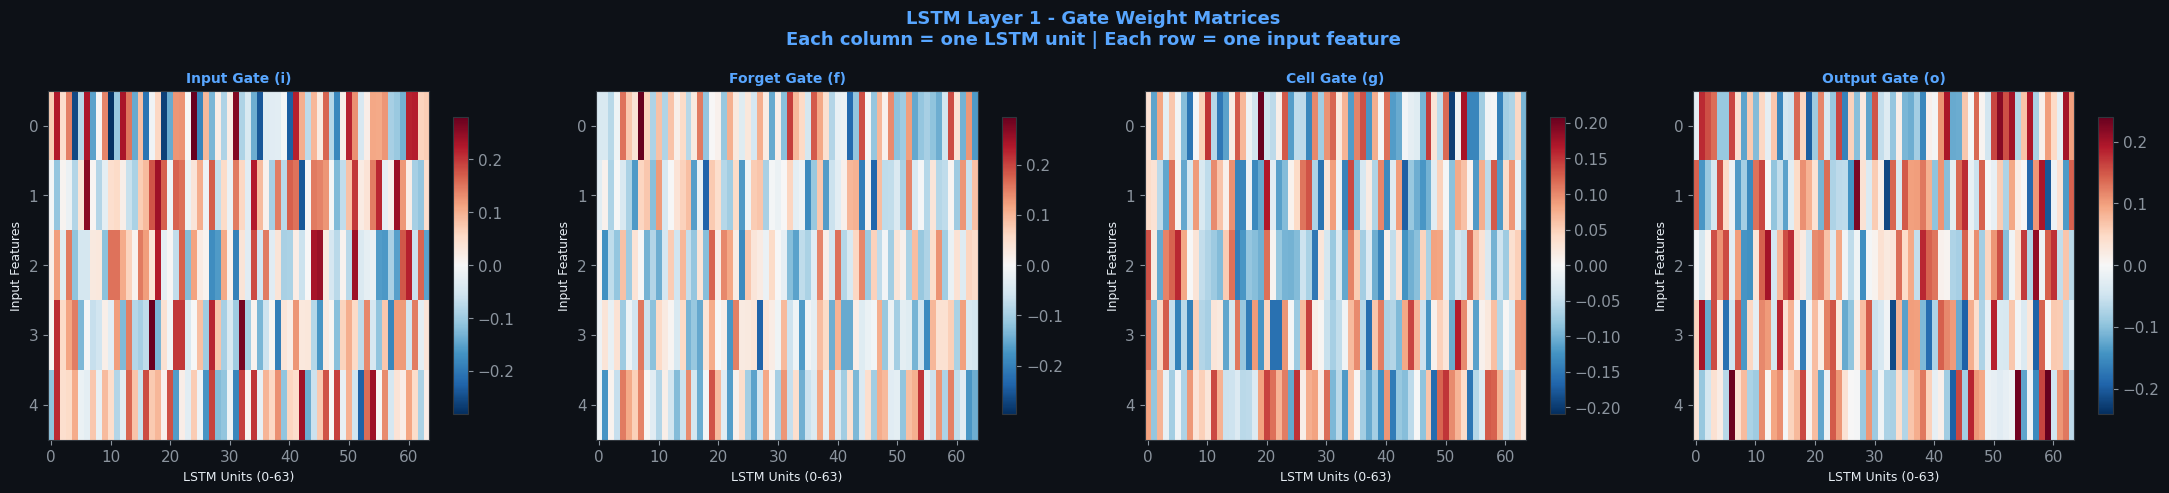

Gate weight analysis saved to lstm_gate_weights.png

Mean |weight| per gate (higher = stronger learned response):
  Input Gate (i)           : 0.0978
  Forget Gate (f)          : 0.0812
  Cell Gate (g)            : 0.0763
  Output Gate (o)          : 0.0880


In [ ]:
# ============================================================
# CELL 13c: LSTM Gate Weight Analysis (Interpretability)
# Visualises learned weight matrices for each gate in LSTM Layer 1.
# Shows which input features each gate responds to most strongly.
# ============================================================

lstm1_weights = lstm_model.get_layer('lstm_1').get_weights()
W_i     = lstm1_weights[0]   # shape: (n_features, 4 * n_units)
n_units = W_i.shape[1] // 4

gate_names = ['Input Gate (i)', 'Forget Gate (f)', 'Cell Gate (g)', 'Output Gate (o)']

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle(
    'LSTM Layer 1 - Gate Weight Matrices\nEach column = one LSTM unit | Each row = one input feature',
    fontsize=13, fontweight='bold', color='#58a6ff'
)

for k, (ax, name) in enumerate(zip(axes, gate_names)):
    gate_W = W_i[:, k * n_units:(k + 1) * n_units]
    vmax   = np.abs(gate_W).max()
    im     = ax.imshow(gate_W, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(name, color='#58a6ff', fontsize=10, fontweight='bold')
    ax.set_xlabel('LSTM Units (0-63)', fontsize=9)
    ax.set_ylabel('Input Features', fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.85)

plt.tight_layout()
plt.savefig('lstm_gate_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gate weight analysis saved to lstm_gate_weights.png')

print('\nMean |weight| per gate (higher = stronger learned response):')
for k, name in enumerate(gate_names):
    gw = W_i[:, k * n_units:(k + 1) * n_units]
    print(f'  {name:<25s}: {np.abs(gw).mean():.4f}')